In [1]:
!kaggle datasets download -d andrewmvd/hard-hat-detection -p ~/HelmetGuard/data_raw --unzip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
 99%|█████████████████████████████████████▋| 1.21G/1.22G [00:00<00:00, 3.20GB/s]
100%|██████████████████████████████████████| 1.22G/1.22G [00:00<00:00, 3.22GB/s]


In [ ]:
!ls 

test.ipynb


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="qC9dQbvQo1XpGxU58T4E")
project = rf.workspace("khoi-o1hua").project("helmet-detect-isqhh")
version = project.version(2)
dataset = version.download("yolov8")
                

  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.6 MB/s  0:00:02 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 28.5 MB/s  0:00:00
Using cached python_dotenv-1.2.1-py3-none-any.whl (21 kB)
  Attempting uninstall: idna━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
    Found existing installation: idna 3.11╺━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
    Uninstalling idna-3.11:━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
      Successfully uninstalled idna-3.11m╺━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [roboflow]━━ 7/8 [roboflow]-headless]
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to helmet-detect-2 in yolov8:: 100%|██████████| 114/114 [00:00<00:00, 13241.50it/s]


In [4]:
!ls dataset | head
!cat dataset/data.yaml

ls: cannot access 'dataset': No such file or directory
cat: dataset/data.yaml: No such file or directory


In [4]:
import os
DATASET_DIR = "/home/admin/Documents/HelmetGuard/dataset/helmet-detect-2"
YAML_PATH = os.path.join(DATASET_DIR, "data.yaml")

print(YAML_PATH)

/home/admin/Documents/HelmetGuard/dataset/helmet-detect-2/data.yaml


In [5]:
from ultralytics import YOLO

# 1. Khởi tạo model YOLOv8 Nano 
model = YOLO('yolov8n.pt')

# 2. Bắt đầu quá trình huấn luyện
results = model.train(
    data='/home/admin/Documents/HelmetGuard/dataset/helmet-detect-2/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,  
    project='runs/detect',
    name='train_helmet'
)

print("Weights: runs/detect/train_helmet/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/admin/Documents/HelmetGuard/dataset/helmet-detect-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mo

1. OVERVIEW TRAINING CHART (results.png):
- If the loss curves go down and mAP goes up, the model is learning very well.


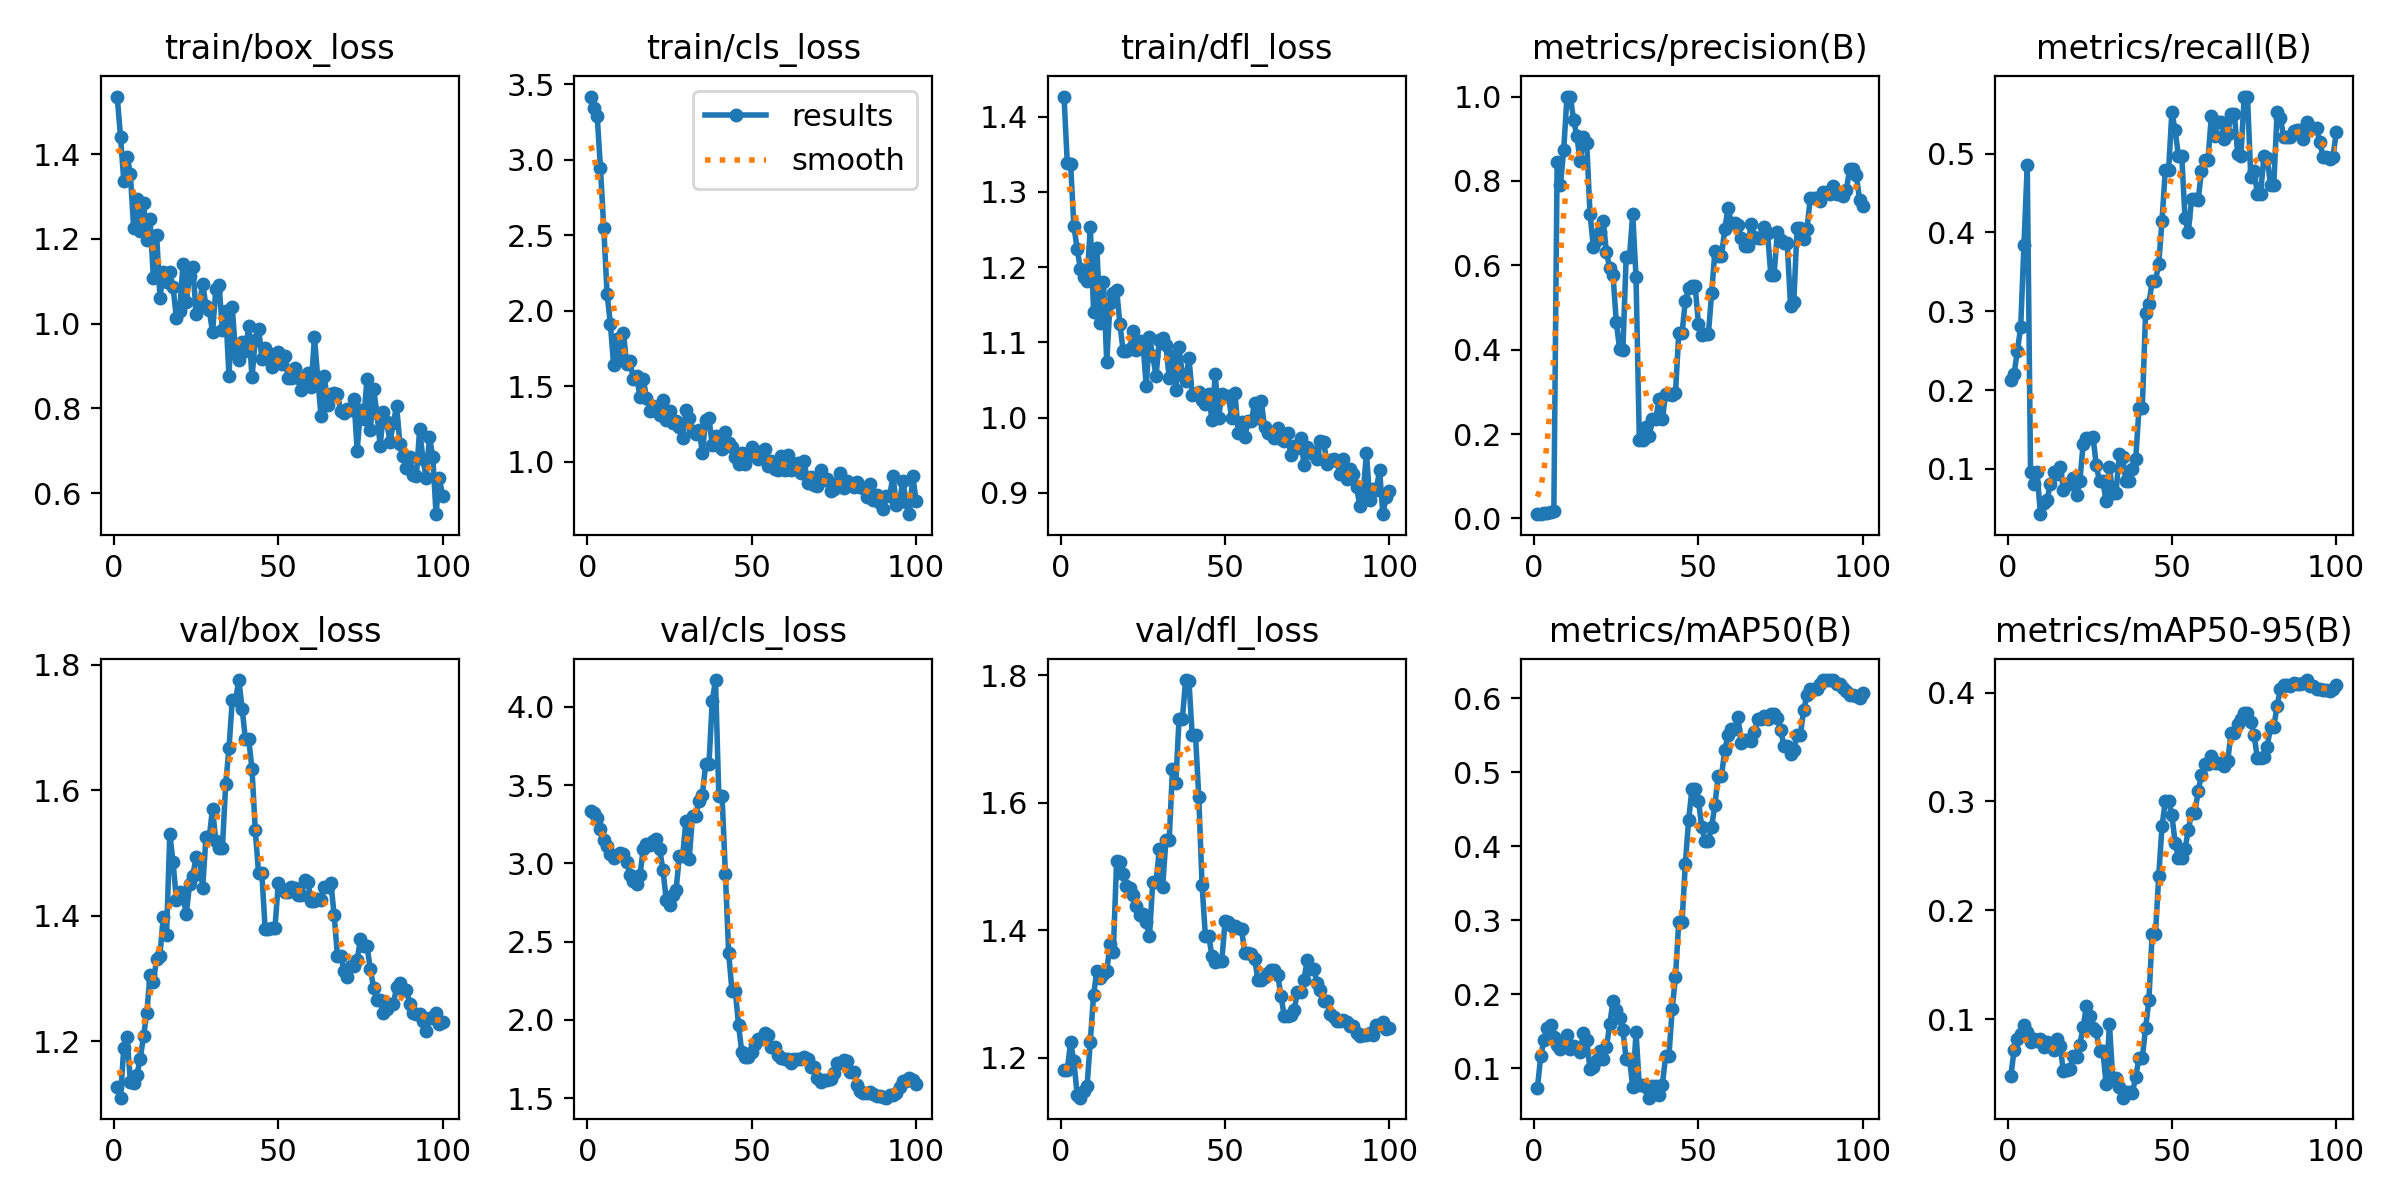


2. CONFUSION MATRIX (confusion_matrix.png):
- Check if the model confuses 'person' with 'helmet'.


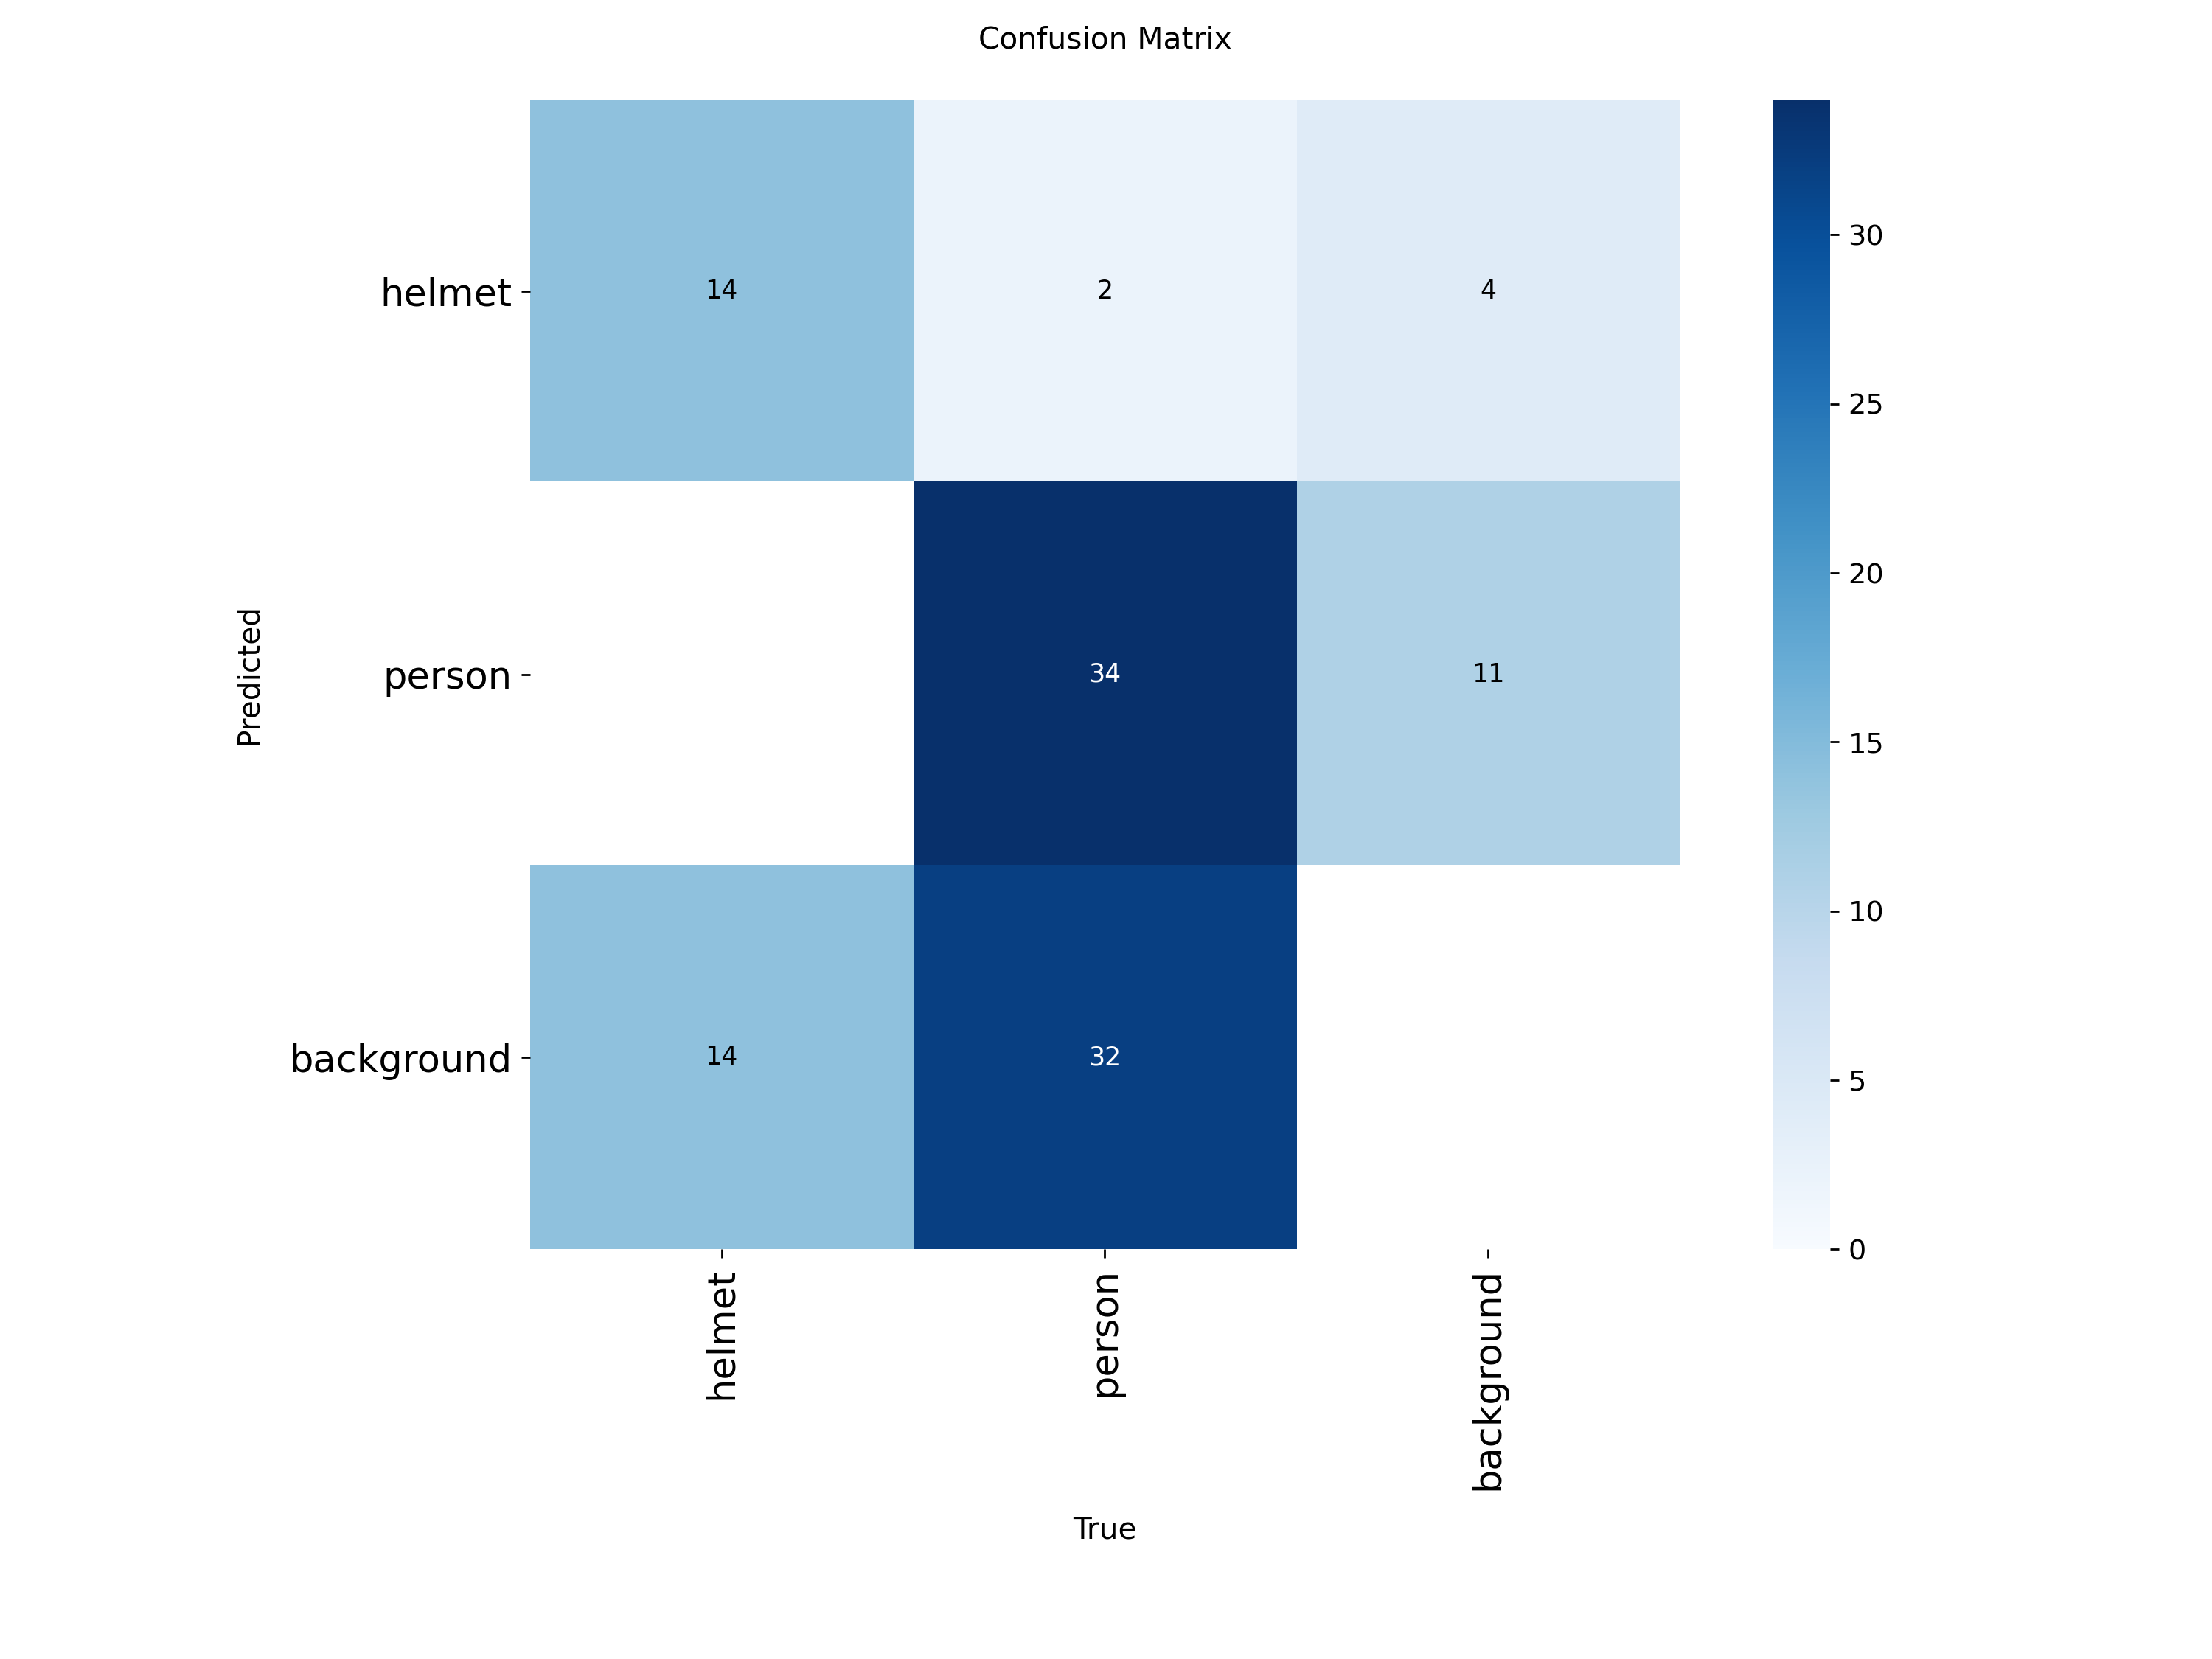


3. PRECISION-RECALL CURVE (BoxPR_curve.png):
- The closer the curve is to the top-right corner (larger area under the curve), the better the model.


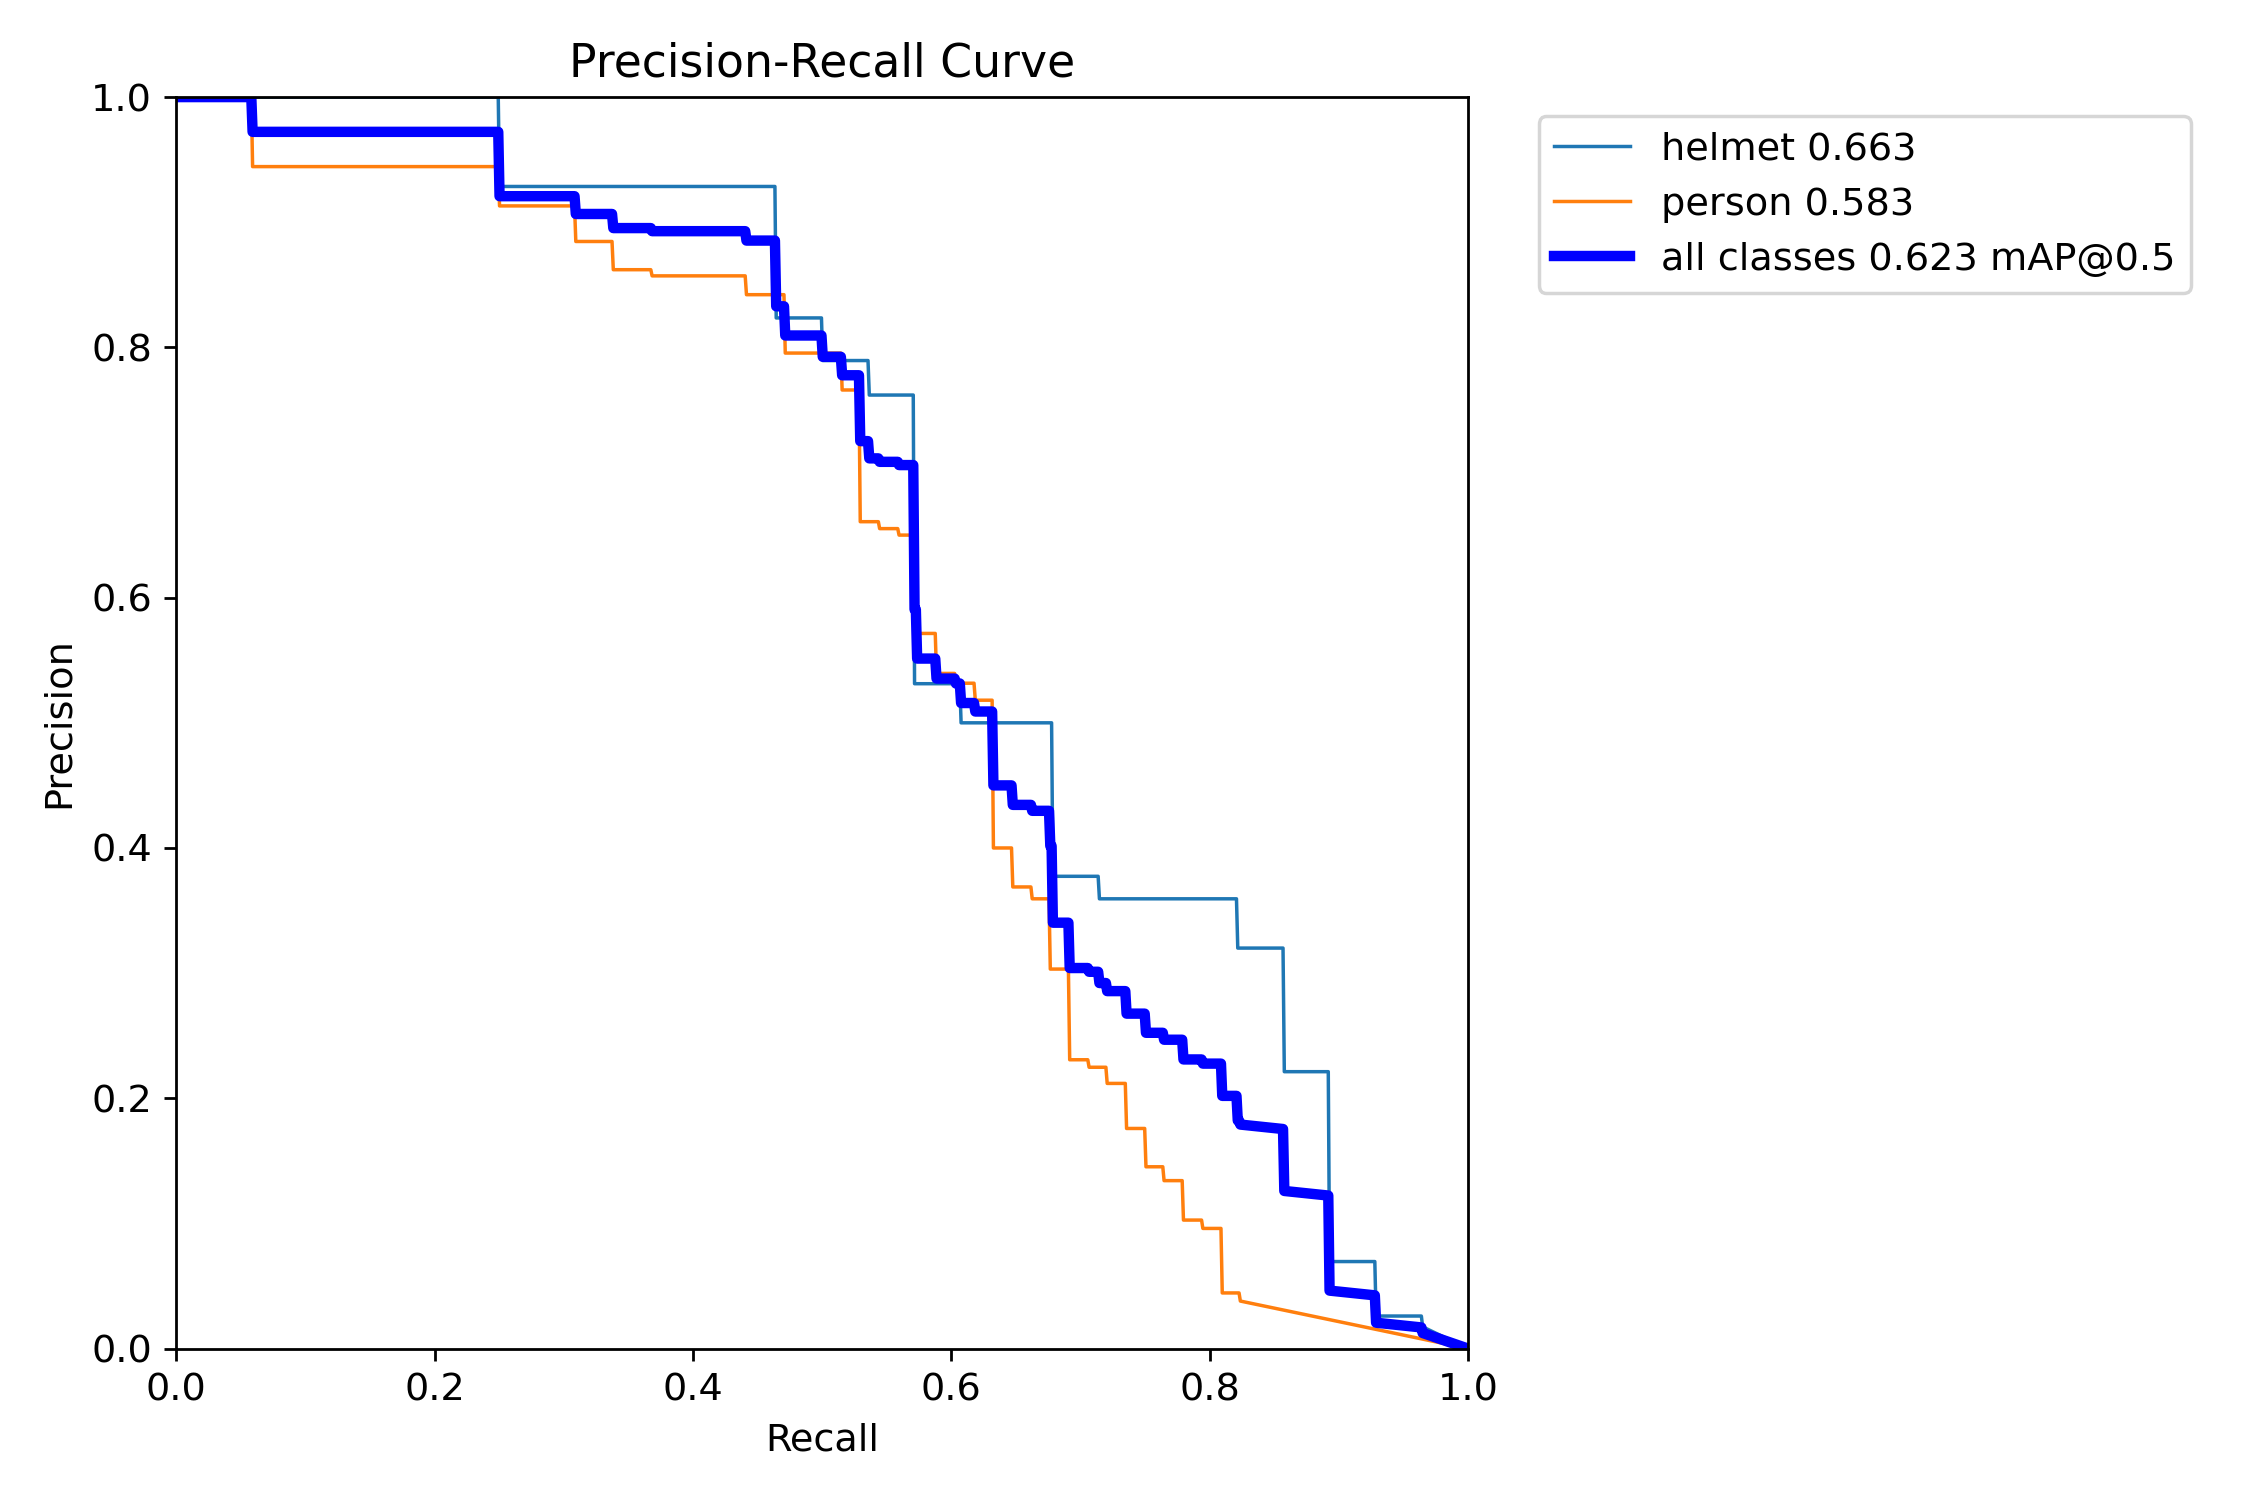


4. ACTUAL PREDICTIONS ON VALIDATION SET (val_batch0_pred.jpg):
- See for yourself if the model's bounding boxes fit tightly around people and helmets.


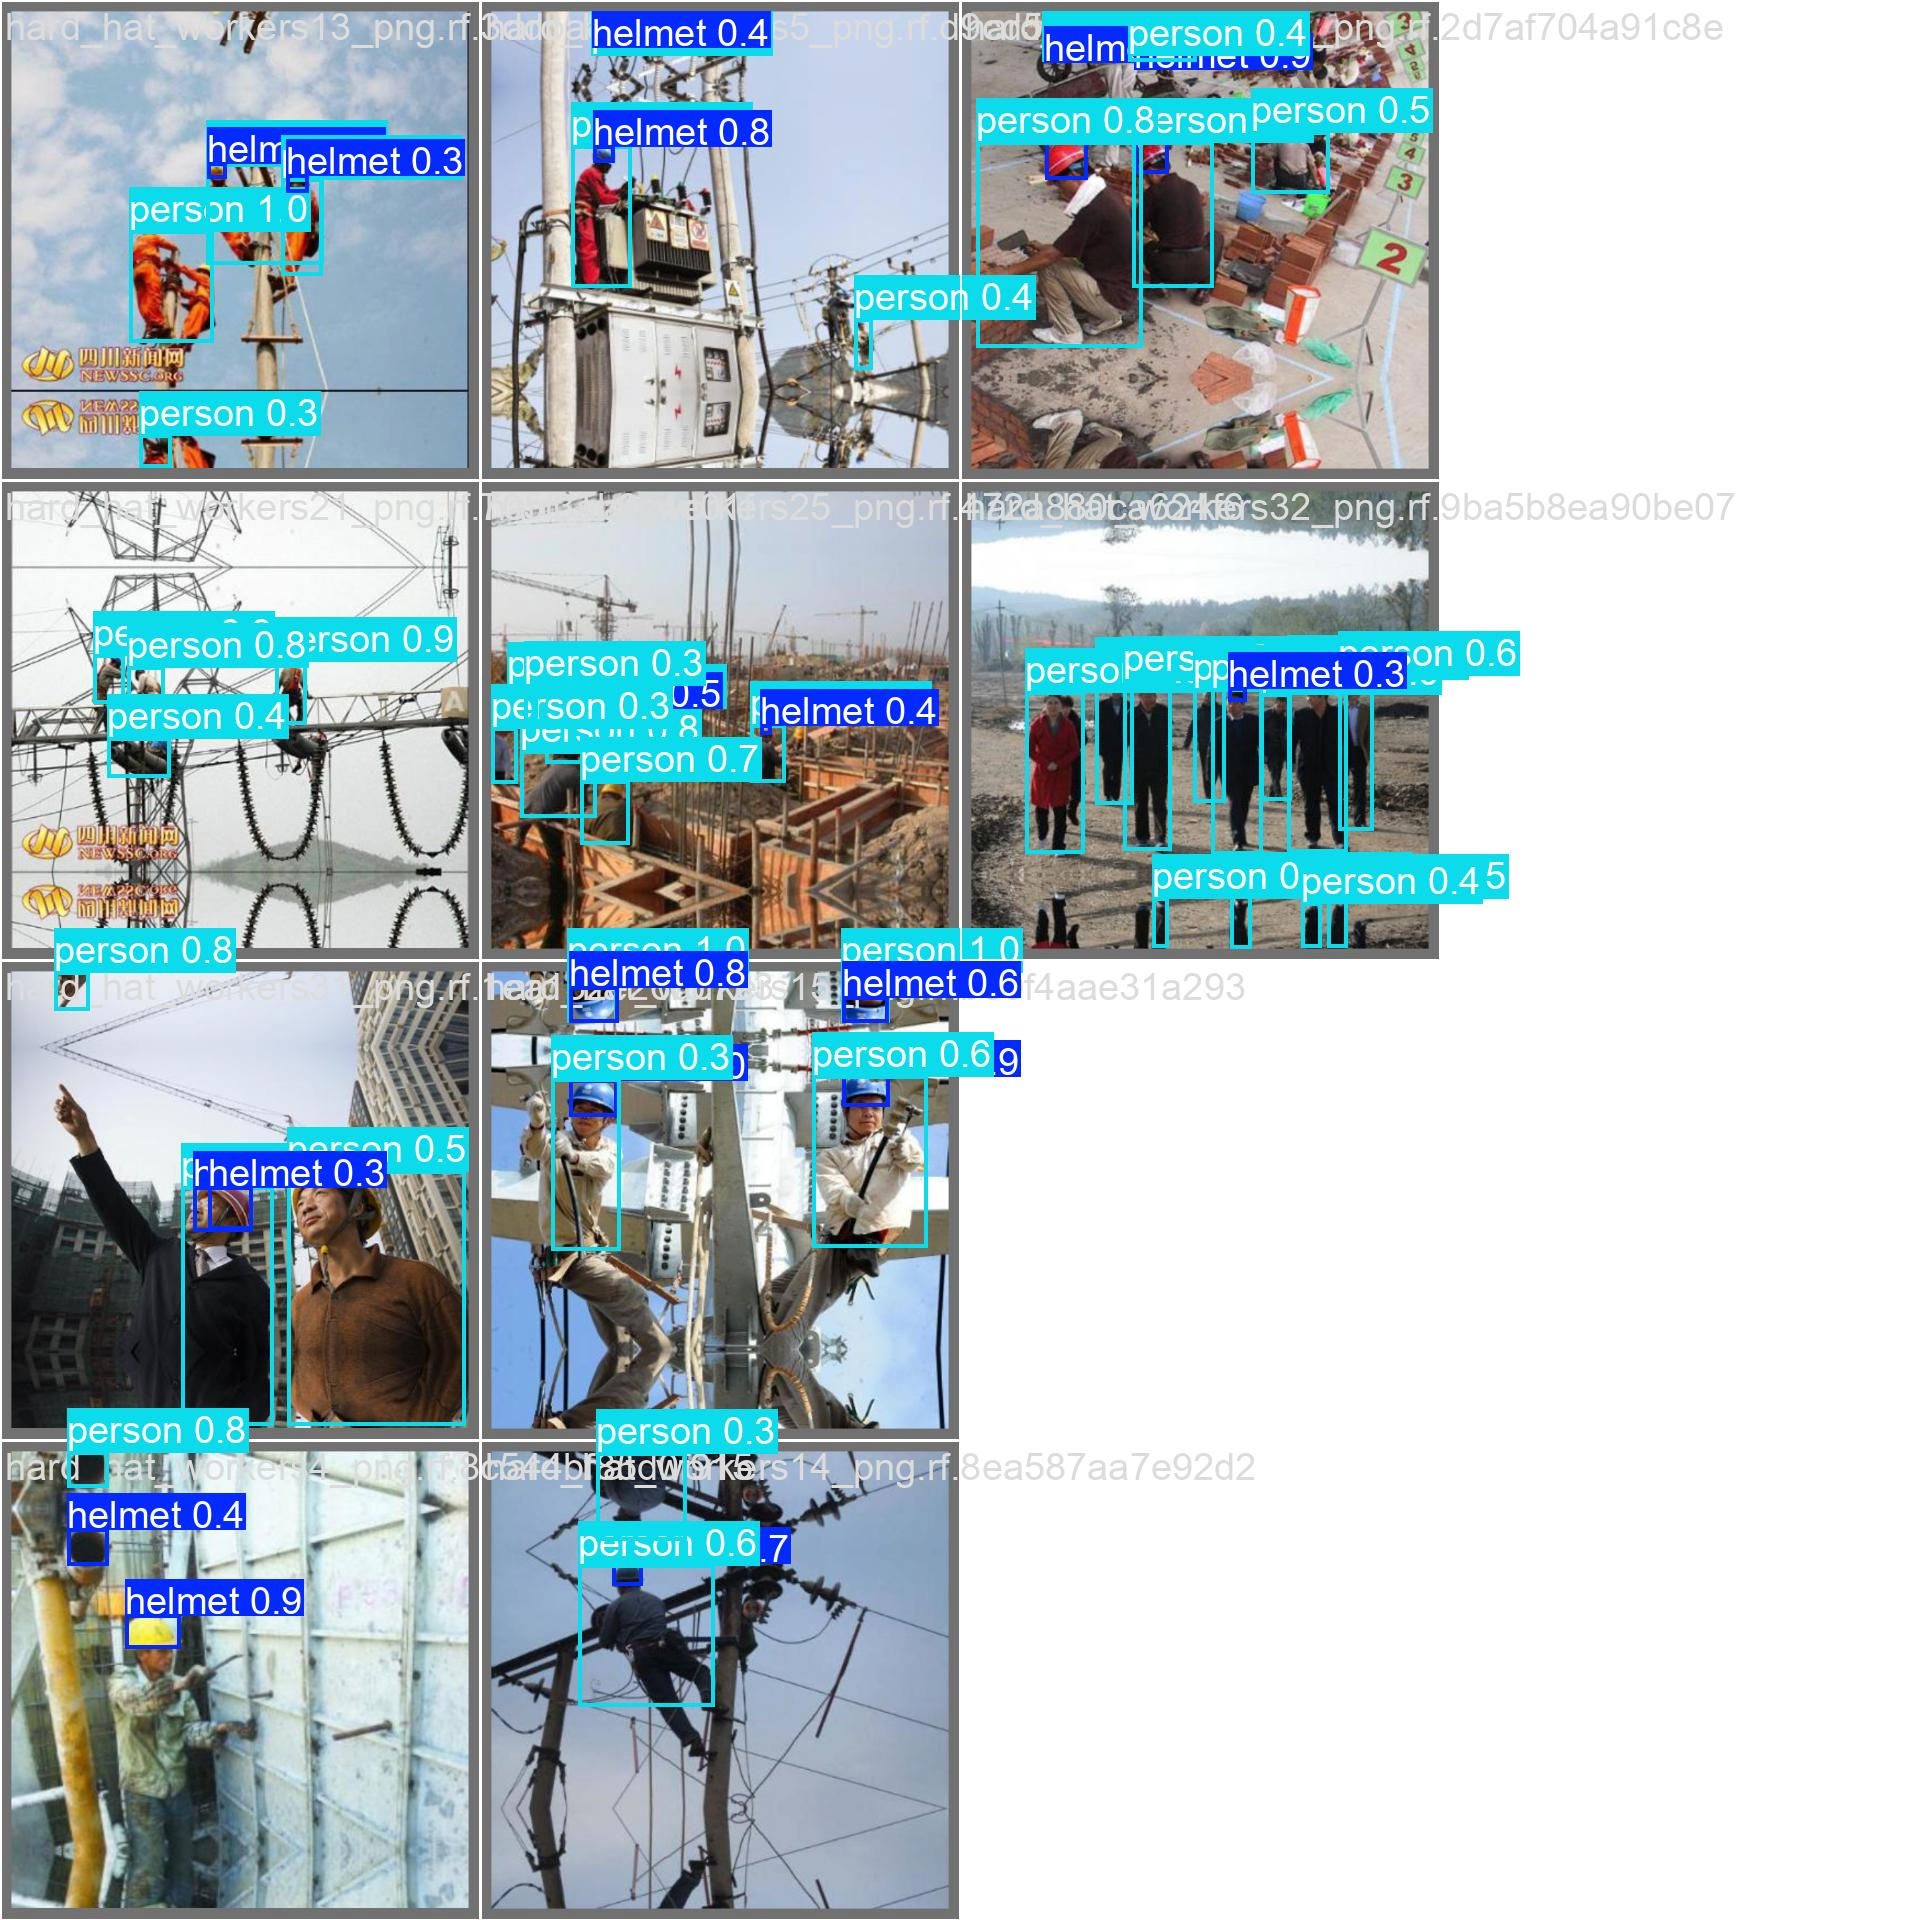

In [6]:
from IPython.display import Image, display

# Relative path from test.ipynb to the results folder
result_dir = 'runs/detect/runs/detect/train_helmet'

# 1. Display the Overview Chart (Loss and mAP)
print("1. OVERVIEW TRAINING CHART (results.png):")
print("- If the loss curves go down and mAP goes up, the model is learning very well.")
display(Image(filename=f'{result_dir}/results.png', width=1000))

# 2. Display the Confusion Matrix
print("\n2. CONFUSION MATRIX (confusion_matrix.png):")
print("- Check if the model confuses 'person' with 'helmet'.")
display(Image(filename=f'{result_dir}/confusion_matrix.png', width=800))

# 3. Display the Precision-Recall curve
print("\n3. PRECISION-RECALL CURVE (BoxPR_curve.png):")
print("- The closer the curve is to the top-right corner (larger area under the curve), the better the model.")
display(Image(filename=f'{result_dir}/BoxPR_curve.png', width=800))

# 4. Display the actual test image on the Validation set
print("\n4. ACTUAL PREDICTIONS ON VALIDATION SET (val_batch0_pred.jpg):")
print("- See for yourself if the model's bounding boxes fit tightly around people and helmets.")
display(Image(filename=f'{result_dir}/val_batch0_pred.jpg', width=1000))


image 1/1 /home/admin/Documents/HelmetGuard/dataset/helmet-detect-2/valid/images/hard_hat_workers15_png.rf.b89f4aae31a293cd9d01f578c58cd857.jpg: 640x640 3 helmets, 5 persons, 2.7ms
Speed: 1.1ms preprocess, 2.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


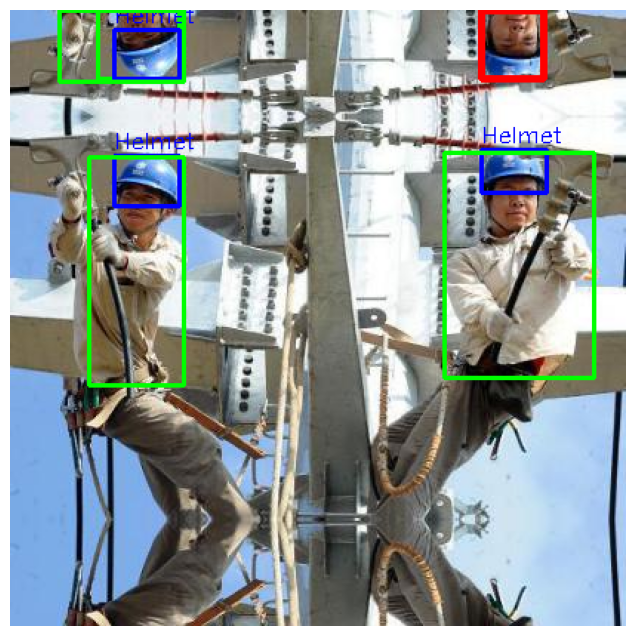

In [8]:
%matplotlib inline
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load trọng số model bạn vừa train xong
model_path = 'runs/detect/runs/detect/train_helmet/weights/best.pt'
model = YOLO(model_path)

# 2. Lấy tấm ảnh đầu tiên trong tập Validation để test
img_list = glob.glob('/home/admin/Documents/HelmetGuard/dataset/helmet-detect-2/valid/images/*.jpg')
test_img_path = img_list[0]

# Chạy YOLO dự đoán
results = model(test_img_path)
result = results[0]


img = cv2.imread(test_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Phân loại bounding box thành 2 danh sách riêng
persons = []
helmets = []

for box in result.boxes:
    cls_id = int(box.cls[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    
    if cls_id == 1:    # Class 1 là person
        persons.append((x1, y1, x2, y2))
    elif cls_id == 0:  # Class 0 là helmet
        helmets.append((x1, y1, x2, y2))

# ===================================================
# 4. THỰC THI LOGIC NO_HELMET
# ===================================================
for (px1, py1, px2, py2) in persons:
    # Lấy tọa độ Y của ranh giới 1/3 phía trên cơ thể
    head_y_bottom = py1 + (py2 - py1) // 3
    
    has_helmet = False
    
    # Kiểm tra xem có mũ nào đè lên vùng đầu không
    for (hx1, hy1, hx2, hy2) in helmets:
        if (px1 < hx2 and px2 > hx1 and py1 < hy2 and head_y_bottom > hy1):
            has_helmet = True
            # Vẽ khung mũ (Xanh dương)
            cv2.rectangle(img, (hx1, hy1), (hx2, hy2), (0, 0, 255), 2)
            cv2.putText(img, 'Helmet', (hx1, hy1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
            break
            
    if has_helmet:
        # Có mũ -> Khung người màu Xanh lá
        cv2.rectangle(img, (px1, py1), (px2, py2), (0, 255, 0), 2)
    else:
        # KHÔNG MŨ -> Khung người màu Đỏ + Cảnh báo
        cv2.rectangle(img, (px1, py1), (px2, py2), (255, 0, 0), 3)
        cv2.putText(img, 'NO_HELMET', (px1, py1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

# 5. Hiển thị ảnh kết quả ra màn hình
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
import cv2
from ultralytics import YOLO

# 1. Load  model
model_path = 'runs/detect/runs/detect/train_helmet/weights/best.pt'
model = YOLO(model_path)

# 2. Define input video and configure output video
video_path = 'demo/demo_helmet.mp4'  
cap = cv2.VideoCapture(video_path)

# Get original video properties (width, height, frames per second)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Create VideoWriter object to save the output video
out = cv2.VideoWriter('demo_helmet_guard.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
if out == null :
    print("temp img")1

print("Processing video with RTX 4060, please wait...")

# 3. Process the video frame by frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        # Stop if end of video is reached
        break

    # Run YOLO inference (verbose=False to keep terminal clean)
    results = model(frame, verbose=False)
    result = results[0]

    persons = []
    helmets = []

    # Classify bounding boxes
    for box in result.boxes:
        cls_id = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        if cls_id == 1:    # ID 1 is person
            persons.append((x1, y1, x2, y2))
        elif cls_id == 0:  # ID 0 is helmet
            helmets.append((x1, y1, x2, y2))

    # Apply NO_HELMET business logic
    for (px1, py1, px2, py2) in persons:
        # Define the top 1/3 of the person's bounding box as the head region
        head_y_bottom = py1 + (py2 - py1) // 3
        has_helmet = False
        
        # Check if any helmet overlaps with the head region
        for (hx1, hy1, hx2, hy2) in helmets:
            if (px1 < hx2 and px2 > hx1 and py1 < hy2 and head_y_bottom > hy1):
                has_helmet = True
                # Draw bounding box for the helmet (Blue)
                cv2.rectangle(frame, (hx1, hy1), (hx2, hy2), (0, 0, 255), 2)
                cv2.putText(frame, 'Helmet', (hx1, hy1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
                break
                
        if has_helmet:
            # Has helmet -> Draw green bounding box for person
            cv2.rectangle(frame, (px1, py1), (px2, py2), (0, 255, 0), 2)
        else:
            # NO HELMET -> Draw red bounding box for person + warning text
            cv2.rectangle(frame, (px1, py1), (px2, py2), (255, 0, 0), 3)
            cv2.putText(frame, 'NO_HELMET', (px1, py1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    # Write the annotated frame to the output video
    out.write(frame)

# Release resources
cap.release()
out.release()
print("Video exported successfully! Open 'demo_helmet_guard.mp4' to check the result.")

NameError: name 'null' is not defined